# Índice

Nesta segunda sesión de prácticas cubriremos os seguintes aspectos:
1. Método de segmentación por crecemento de rexións
2. Postprocesado de segmentacións mediante operacións morfolóxicas
3. Cálculo de métricas de segmentación

Primeiro importamos as librarías necesarias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import rescale
from skimage.morphology import binary_erosion, binary_dilation, binary_opening, binary_closing

from pathlib import Path
import zipfile
from urllib import request

Dado que faremos probas co conxunto de datos FruitSeg30, imos descargalo e descomprimilo

In [ ]:
url = 'https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/vkht8pfsp3-3.zip'
dataset_name = Path('FruitSeg30_Segmentation Dataset & Mask Annotations')
output_zip_path = Path('FruitSeg30.zip')
output_dir = Path('FruitSeg30')

if not output_dir.is_dir():
    request.urlretrieve(url, output_zip_path)
    with zipfile.ZipFile(output_zip_path, 'r') as zip_ref:
        zip_ref.extractall()

    (dataset_name/output_dir).rename(output_dir)

    output_zip_path.unlink()
    dataset_name.rmdir()

Ademáis, dado que nesta práctica imos traballar co software 3D Slicer, imos a instalalo seguindo as instrucións dispoñibles na súa páxina web oficial:

1. Visita a páxina oficial de descargas de [3D Slicer](https://download.slicer.org/).
2. Descarga a versión adecuada para o teu sistema operativo (fíxate que para os sistemas Linux é preciso instalar unhas [dependencias](https://slicer.readthedocs.io/en/latest/user_guide/getting_started.html#linux) previamente).
3. Segue as instrucións de instalación proporcionadas na páxina.

# 1. Método de segmentación baseado no crecemento de rexións

## Descrición e uso do método en Python

Este método parte de uns puntos iniciais (puntos semente) e iterativamente trata de determinar se os puntos adxacentes deberían ser engadidos á rexión.

As premisas das que parte son as seguintes:
- Todos os píxeles deben de pertencer a algunha rexión
- Os puntos dunha rexión deben estar conectados
- Un mesmo punto non pode pertencer a dúas rexións diferentes
- Os puntos da mesma rexión deben ser similares segundo algún criterio predefinido

O pseudocódigo básico deste algoritmo é o seguinte:

```text
Entradas:
    I: imaxe
    S: conxunto de puntos semente {s1, s2, ..., sk}
    C: criterio de similaridade (función que decide se un píxel p debe unirse á rexión i)

Saída:
    L: imaxe de etiquetas co id de rexión para cada píxel (ou -1 se non asignado)

Procedemento CrecementoRexions(I, S, C, N):
    1. Inicializar L (imaxe de etiquetas) a -1
    2. Para cada semente s_i:
       - L[s_i] ← i
       - Engadir s_i á cola Q
    3. Mentres Q non estea baleira:
       - Extraer píxel p da cola
       - Para cada veciño v de p:
         * Se L[v] == -1 e C(v, i) é verdadeiro:
           - L[v] ← i
           - Engadir v á cola Q
    4. Devolver L
```

A función C é crucial e pode ser adaptada segundo a aplicación específica. Un exemplo sería $C(v, i) = |I[v] − \mu_i| \leq \tau$, onde $\mu_i$ é a media actual dos píxeles na rexión $i$ e $\tau$ é un umbral predefinido.

Primeiro imos probar a implementar este algoritmo.

In [ ]:
# Función auxiliar para obter as coordenadas dos píxeles veciños (4-conexión)
def get_neighbors(image, p):
    neighbors = []
    for delta in [         (0, -1),
                  (-1, 0),          (1, 0), 
                           (0, 1)]:
        neighbor = (p[0] + delta[0], p[1] + delta[1])
        if 0 <= neighbor[0] < image.shape[0] and 0 <= neighbor[1] < image.shape[1]:
            neighbors.append(neighbor)
    return neighbors

def region_growing(image, seed_points, similarity_criterion):
    """
    Segmentación por crecemento de rexións.
    
    Entradas:
        image: imaxe
        seed_points: conxunto de puntos semente {s1, s2, ..., sk}
        similarity_criterion: criterio de similaridade (función que decide se un píxel p debe unirse á rexión i)

    Saída:
        result: imaxe de etiquetas co id de rexión para cada píxel (ou -1 se non asignado)
    """

    # Inicialización
    result = -1 * np.ones(image.shape, dtype=int)  # Imaxe de etiquetas
    region_id = 0
    queue = deque()

    # Engadir sementes á cola e etiquetalas
    for s in seed_points:
        result[s] = region_id
        queue.append((s, region_id))
        region_id += 1

    # Crecemento de rexións
    while queue:
        p, rid = queue.popleft()
        for n in get_neighbors(image, p):
            if result[n] == -1 and similarity_criterion(image[n], rid, result):
                result[n] = rid
                queue.append((n, rid))

    return result

Ahora imos probar a aplicar este método para segmentar unha imaxe TAC de cerebro.

In [ ]:
image = imread('https://www.saem.org/images/default-source/academy-images/cdem/picture18e8c89c7-3a6d-4e93-9024-5c36665baef2.png?sfvrsn=3371288a_1')[: , : , :3]
image = rgb2gray(image)

plt.imshow(image, cmap='gray')
plt.title("Imaxe orixinal")
plt.show()

 Primeiro intentaremos segmentar os ventrículos cerebrais fixando un único punto semente nesa zona. Ademáis, definiremos o criterio de similaridade para engadir píxeles cuxo valor estea a unha distancia menor que un umbral tau da media actual da rexión.

In [ ]:
seed_points = ((200,200),) # Punto semente na coordenada (x=200, y=200). x é a columna e y é a fila.

def criterio_similaridade(pixel_value, region_id, L):
    # C: |I[v] − media_i| ≤ τ
    media_i = np.mean(image[L == region_id])
    tau = 0.15  # Limiar de similaridade
    return np.abs(pixel_value - media_i) <= tau

Ahora probamos a executar a función de crecemento de rexións

In [ ]:
L = region_growing(image, seed_points, criterio_similaridade)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Imaxe orixinal")
plt.imshow(image, cmap='gray')

for s in seed_points:
    plt.plot(s[1], s[0], 'ro')
plt.subplot(1, 2, 2)
plt.title(f"Segmentación por crecemento de rexións con tau = 0.15")
plt.imshow(L, cmap='gray')
plt.show()

Ahora imos intentar segmentar a rexión ventricular e o cranio fixando dous puntos semente, un en cada rexión.

In [ ]:
seed_points = ((100,100),(200,200))

L = region_growing(image, seed_points, criterio_similaridade)
print(np.unique(L))
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Imaxe orixinal")
plt.imshow(image, cmap='gray')

for s in seed_points:
    plt.plot(s[1], s[0], 'ro')  # Note: (x, y) = (col, row)
plt.subplot(1, 2, 2)
plt.title(f"Segmentación por crecemento de rexións con τau = 0.15")
plt.imshow(L, cmap='nipy_spectral')
plt.show()

Para visualizar mellor o proceso de crecemento de rexións, imos modificar a función orixinal para que vaia devolvendo o estado intermedio da segmentación despois de procesar cada píxel pendente. Isto podemos facelo convertindo a función nun xerador (eliminando o `return` e substituíndoos por `yield` despois de cada iteración).

In [ ]:
def crecemento_rexions_interactivo(image, seed_points, similarity_criterion):
    """
    Segmentación por crecemento de rexións (con xerador).
    
    Entradas:
        image: imaxe
        seed_points: conxunto de puntos semente {s1, s2, ..., sk}
        similarity_criterion: criterio de similaridade (función que decide se un píxel p debe unirse á rexión i)

    Saída:
        result: imaxe de etiquetas intermedio co id de rexión para cada píxel (ou -1 se non asignado)
    """

    result = -1 * np.ones(image.shape, dtype=int)
    region_id = 0
    queue = deque()

    for s in seed_points:
        result[s] = region_id
        queue.append((s, region_id))
        region_id += 1

    while queue:
        p, rid = queue.popleft()
        for n in get_neighbors(image, p):
            if result[n] == -1 and similarity_criterion(image[n], rid, result):
                result[n] = rid
                queue.append((n, rid))
        yield result  # Devolve o estado actual da segmentación

Ademais, imos engadir unha terceira semente para intentar segmentar a rexión do tecido cerebral.

In [ ]:
seed_points = ((100,100),(140,140),(200,200))

for i, result in enumerate(crecemento_rexions_interactivo(image, seed_points, criterio_similaridade)):
    if i % 5000 == 0: # Visualizamos o resultado intermedio cada 5000 píxeles procesados
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.title("Imaxe orixinal")
        plt.imshow(image, cmap='gray')
        # Plot seeds
        for s in seed_points:
            plt.plot(s[1], s[0], 'ro')  # Note: (x, y) = (col, row)
        plt.subplot(1, 2, 2)
        plt.title(f"Segmentación por crecemento de rexións (it: {i})")
        plt.imshow(result, cmap='nipy_spectral')
        plt.show()
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Imaxe orixinal")
plt.imshow(image, cmap='gray')
# Plot seeds
for s in seed_points:
    plt.plot(s[1], s[0], 'ro')  # Note: (x, y) = (col, row)
plt.subplot(1, 2, 2)
plt.title(f"Segmentación por crecemento de rexións (it: {i})")
plt.imshow(result, cmap='nipy_spectral')
plt.show()

## Exercicios propostos

1. Proba a modificar os valores de $\tau$ no criterio de similaridade. Que efecto ten o aumento deste valor?
2. Modificar o criterio de similaridade para evitar depender dun limiar fixado manualmente. Podes anexar os píxeles que caen dentro dun rango de intesidades da rexión actual, por exemplo `[percentil25, percentil75]`, ou `[media - 2*desviacion_estandar, media + 2*desviacion_estandar]`.
3. Implementa unha variante do algoritmo que use 8-conexión en vez de 4-conexión. Compara os resultados obtidos con ambas versións.
4. Modifica o algoritmo para que permita a fusión de rexións veciñas que cumpran un criterio de similaridade entre elas despois do crecemento inicial.

# 2. Postprocesado de segmentacións mediante operacións morfolóxicas

Nesta sección imos explorar como mellorar as segmentacións obtidas mediante operacións morfolóxicas, como a dilatación, erosión, apertura e peche. Estas operacións poden axudar a eliminar ruído, pechar buratos, eliminar puntos illados e suavizar os bordes das rexións segmentadas.

## Operacións morfolóxicas básicas

As operacións morfolóxicas son transformacións baseadas na forma dos obxectos nunha imaxe. As máis comúns son:

- **Erosión**: Reduce o tamaño dos obxectos, eliminando píxeles dos bordes
- **Dilatación**: Aumenta o tamaño dos obxectos, engadindo píxeles aos bordes
- **Apertura**: Erosión seguida de dilatación. Elimina pequenos obxectos e ruído
- **Peche**: Dilatación seguida de erosión. Pecha buratos e conecta obxectos próximos

Imos ver como utilizar estas funcións cun exemplo sintético, composto por un recadro branco cun pouco de ruído. Supoñemos que o recadro branco é a rexión de interese que queremos segmentar, e o ruído son píxeles illados que queremos eliminar.

In [ ]:
# Creamos unha imaxe negra cunha rexión central branca
image = np.zeros((100, 100), dtype=bool)
image[30:70, 30:70] = 1  # Rexión central
# Engadimos ruído aleatorio
noise = np.random.rand(100, 100) > 0.98
noisy_image = np.logical_or(image, noise)

plt.imshow(noisy_image, cmap='gray')
plt.title("Imaxe con ruído")
plt.show()

Ahora aplicamos operacións morfolóxicas para ver o seu resultado. Tamén representaremos as esquinas do recadro orixinal para tomar como referencia.

In [ ]:
# Erosión
eroded_image = binary_erosion(noisy_image)
# Dilatación
dilated_image = binary_dilation(noisy_image)
# Apertura
opened_image = binary_opening(noisy_image)
# Peche
closed_image = binary_closing(noisy_image)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(eroded_image, cmap='gray')
axes[0, 0].set_title("Erosión")
axes[0, 0].plot([29.5, 69.5, 69.5, 29.5], [29.5, 29.5, 70.5, 70.5], 'r+')
axes[0, 1].imshow(dilated_image, cmap='gray')
axes[0, 1].set_title("Dilatación")
axes[0, 1].plot([29.5, 69.5, 69.5, 29.5], [29.5, 29.5, 70.5, 70.5], 'r+')
axes[1, 0].imshow(opened_image, cmap='gray')
axes[1, 0].set_title("Apertura (erosión + dilatación)")
axes[1, 0].plot([29.5, 69.5, 69.5, 29.5], [29.5, 29.5, 70.5, 70.5], 'r+')
axes[1, 1].imshow(closed_image, cmap='gray')
axes[1, 1].set_title("Peche (dilatación + erosión)")
axes[1, 1].plot([29.5, 69.5, 69.5, 29.5], [29.5, 29.5, 70.5, 70.5], 'r+')

plt.show()

❓ Cal cres no caso anterior que é a operación máis adecuada para preservar a rexión de interese o máis parecida posible á orixinal, eliminando o ruído?

❓ No caso que se amosa a continuación, sucede que o contorno da máscara de segmentación está ben definido, pero existen ocos no interior. Que operación de postprocesado sería a máis adecuada para solucionar este problema? Implementa a solución e comproba o resultado

In [ ]:
category_name = output_dir / "Avocado"
img_id = 1

image = imread(category_name / "Images" / f"{img_id}.jpg")
gt_mask = imread(category_name / "Mask" / f"{img_id}_mask.png")
segmented_image = rgb2gray(image) < 0.45  # Segmentación simple por umbralización

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].imshow(image)
axes[0].set_title("Imaxe orixinal")
axes[0].axis('off')
axes[1].imshow(gt_mask, cmap="gray")
axes[1].set_title("Máscara real (ground truth)")
axes[1].axis('off')
axes[2].imshow(segmented_image, cmap="gray")
axes[2].set_title("Imaxe segmentada")
axes[2].axis('off')

plt.show()

# 3. Cálculo de métricas de segmentación

Para avaliar a calidade dunha segmentación nun problema de segmentación supervisada (no que dispoñemos dunha máscara de referencia ou "ground truth"), podemos empregar diversas métricas que comparan a segmentación obtida coa máscara de referencia. Para exemplificar o uso destas métricas imos recuperar o dataset FruitSeg30.

## Métricas comúns de segmentación

Dado que a segmentación semántica é un problema de clasificación a nivel de píxel, podemos empregar varias métricas comúns de clasificación. Ditas métricas poden calcularse a partir dunha matriz de confusión que compara os píxeles predicidos cos píxeles da máscara de referencia. Se consideramos unha segmentación binaria (obxecto vs fondo), as métricas máis comúns son:

1. **Exactitude (Accuracy)**: Proporción de píxeles correctamente clasificados sobre o total de píxeles.
2. **Precisión (Precision)**: Proporción de verdadeiros positivos sobre o total de positivos predicidos.
3. **Sensibilidade (Recall)**: Proporción de verdadeiros positivos sobre o total de positivos reais.
4. **F1-Score**: Media harmónica entre a precisión e a sensibilidade.
5. **IoU (Intersection over Union)**: Proporción entre a intersección e a unión das máscaras predicidas e de referencia.

Imos probar a realizar unha segmentación de proba utilizando unha imaxe da clase `Banana`. Faremos unha umbralización simple para obter unha máscara de segmentación binaria.

In [ ]:
category_name = output_dir / "Banana"
img_id = 1

image = imread(category_name / "Images" / f"{img_id}.jpg")
gt_mask = imread(category_name / "Mask" / f"{img_id}_mask.png")
segmented_image = rgb2gray(image) < 0.55  # Exemplo de segmentación binaria

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].imshow(image)
axes[0].set_title("Imaxe orixinal")
axes[0].axis('off')
axes[1].imshow(gt_mask, cmap="gray")
axes[1].set_title("Máscara real (ground truth)")
axes[1].axis('off')
axes[2].imshow(segmented_image, cmap="gray")
axes[2].set_title("Imaxe segmentada")
axes[2].axis('off')
plt.show()

Primeiro representamos a matriz de confusión e as métricas de segmentación obtidas.

In [ ]:
cm = np.zeros((2, 2), dtype=int)
for i in range(gt_mask.shape[0]):
    for j in range(gt_mask.shape[1]):
        gt_pixel = 1 if gt_mask[i, j] > 0 else 0
        seg_pixel = 1 if segmented_image[i, j] else 0
        cm[gt_pixel, seg_pixel] += 1

plt.imshow(cm, cmap='Blues')
plt.title("Matriz de confusión")
plt.xlabel("Predición")
plt.ylabel("Ground Truth")
plt.colorbar()
plt.xticks([0, 1], ['Fondo (clase negativa)', 'Obxecto (clase positiva)'])
plt.yticks([0, 1], ['Fondo (clase negativa)', 'Obxecto (clase positiva)'])
plt.text(0, 0, f"True Negative (TN):\n{cm[0, 0]}", ha='center', va='center', color='red')
plt.text(0, 1, f"False Positive (FP):\n{cm[0, 1]}", ha='center', va='center', color='red')
plt.text(1, 0, f"False Negative (FN):\n{cm[1, 0]}", ha='center', va='center', color='red')
plt.text(1, 1, f"True Positive (TP):\n{cm[1, 1]}", ha='center', va='center', color='red')
plt.show()

Ahora imos visualizar as rexións TP, TN, FP e FN na imaxe segmentada para entender mellor onde se cometeron erros.

In [ ]:
tp = np.logical_and(segmented_image == 1, gt_mask > 0)
tn = np.logical_and(segmented_image == 0, gt_mask == 0)
fp = np.logical_and(segmented_image == 1, gt_mask == 0)
fn = np.logical_and(segmented_image == 0, gt_mask > 0)
visualization = np.zeros((*segmented_image.shape, 3), dtype=np.uint8)
visualization[tn] = [0, 0, 0]  # Negro
visualization[tp] = [0, 255, 0]  # Verde
visualization[fp] = [255, 0, 0]  # Vermello
visualization[fn] = [0, 0, 255]  # Azul
plt.figure(figsize=(7, 7))
plt.imshow(visualization)
plt.title("Visualización de TP (verde), TN (negro), FP (vermello) e FN (azul)")
handles = [
    plt.Line2D([0], [0], color="green", lw=4, label="True positive (TP)"),
    plt.Line2D([0], [0], color="black", lw=4, label="True negative (TN)"),
    plt.Line2D([0], [0], color="red", lw=4, label="False positive (FP)"),
    plt.Line2D([0], [0], color="blue", lw=4, label="False negative (FN)"),
]
plt.legend(handles=handles, loc="upper left")
plt.axis("off")
plt.show()

A partir dos valores da matriz de confusión podemos calcular as métricas de clasificación mencionadas anteriormente.

- Accuracy:
$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$

- Precision:
$\text{Precision} = \frac{TP}{TP + FP}$

- Recall (Sensibilidade):
$\text{Recall} = \frac{TP}{TP + FN}$

- F1 Score:
$\text{F1 Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$

❓ Implementa a función `calcular_metricas` que reciba a matriz de confusión e imprima o valor das métricas de clasificación. Como interpretas os resultados?

## Métricas específicas de segmentación

No eido específico da segmentación, existen outras métricas que teñen en conta a natureza espacial das imaxes. Unha das máis utilizadas é o Índice de Dice (Dice Coefficient), que mide a superposición entre dúas máscaras binarias.

O Índice de Dice defínese como:

$$
\text{Dice} = \frac{2 \cdot |A \cap B|}{|A| + |B|}
$$

Onde:
- $A$ é a máscara predicida.
- $B$ é a máscara de referencia (ground truth).
- $|A|$ e $|B|$ son as áreas das máscaras $A$ e $B$, respectivamente.

❓ Implementa a función `calcular_dice` que reciba dúas máscaras binarias (predición e ground truth) e devolva o valor do Índice de Dice. Proba esta función coas máscaras obtidas na segmentación de proba anterior.

Outra das métricas máis empregadas é a de Hausdorff, que mide a distancia máxima entre os bordes das rexións segmentadas e as de referencia. Esta métrica é especialmente útil para avaliar a precisión dos contornos segmentados. A métrica de Hausdorff entre dous conxuntos de puntos $A$ e $B$ defínese como:
$$
d_H(A, B) = \max\{\sup_{a \in A} \inf_{b \in B} d(a, b), \sup_{b \in B} \inf_{a \in A} d(b, a)\}
$$

In [ ]:
def hausdorff_distance(gt_mask, predicted_mask):
    """
    Calcula a distancia de Hausdorff entre dúas máscaras de segmentación

    Entradas
    ----------
    gt_mask : Máscara real (ground truth).
    predicted_mask : Máscara predicida.

    Saída
    -------
    A distancia de Hausdorff entre as dúas máscaras.
    """
    
    # Aseguramonos de que as máscaras son binarias
    gt_mask = gt_mask > 0
    predicted_mask = predicted_mask > 0
    
    # Obtemos as coordenadas dos píxeles do obxecto (cor branco)
    coords_gt = np.column_stack(np.nonzero(gt_mask))
    coords_predicted = np.column_stack(np.nonzero(predicted_mask))
    
    # Se algunha das máscaras está baleira, devolvemos infinito
    if coords_gt.size == 0 or coords_predicted.size == 0:
        return np.inf

    # Calculamos todas as distancias euclideas pixel-a-pixel
    dists = np.sqrt(
        np.sum((coords_gt[:, np.newaxis, :] - coords_predicted[np.newaxis, :, :]) ** 2, axis=2)
    )
    # Cada fila de 'dists' contén as distancias dende un píxel en coords_gt a todos os píxeles en coords_predicted
    # Cada columna de 'dists' contén as distancias dende un píxel en coords_predicted a todos os píxeles en coords_gt
    
    # Calculamos as dúas direccións do Hausdorff
    # Isto é, de cada píxel na máscara de ground truth, atopamos a distancia mínima ao píxel máis próximo na máscara predicida (e viceversa)
    forward_hd = np.max(np.min(dists, axis=1))
    backward_hd = np.max(np.min(dists, axis=0))
    
    # Quedamos co máximo das dúas direccións
    return max(forward_hd, backward_hd)

Esta implementación non é a máis eficiente (para iso habería que aplicar transformadas baseadas en distancias). Para que non teñamos problemas de memoria, imos a aplicar esta función á máscara obtida anteriormente pero reduciremos o seu tamaño ao 25%.

In [ ]:
gt_mask_small = rescale(gt_mask, scale=0.25)
segmented_image_small = rescale(segmented_image, scale=0.25)

hausdorff_distance(gt_mask_small, segmented_image_small)

Hai que ter en conta que esta métrica pode ser moi sensible a *outliers*, é dicir, a píxeles que están moi afastados do resto da rexión segmentada. Para mitigar este efecto, pódense empregar variantes como a distancia de Hausdorff parcial, que considera un percentil específico das distancias en vez do valor máximo. A modificación a realizar na función anterior sería calcular o percentil desexado das distancias en vez do máximo nas dúas direccións. É dicir, habería que substituír estas dúas liñas de código

```python
    forward_hd = np.max(np.min(dists, axis=1))
    backward_hd = np.max(np.min(dists, axis=0))
```

por estas outras:

```python
    forward_hd = np.percentile(np.min(dists, axis=1), 95)
    backward_hd = np.percentile(np.min(dists, axis=0), 95)
```

Tamén é importante aclarar que a métrica de Hausdorff está en píxeles e, polo tanto, a súa interpretación depende da resolución espacial da imaxe. Por exemplo, unha distancia de Hausdorff de 5 píxeles pode ser significativa nunha imaxe de baixa resolución, pero pode ser desprezable nunha imaxe de alta resolución. No caso de que teñamos a información da resolución espacial (tamén coñecida como *spacing*), podemos convertar a distancia de píxels a unidades físicas. Por exemplo, se o *spacing* é de 0.5 mm/píxel, unha distancia de Hausdorff de 10 píxeles correspondería a 5 mm na realidade física.

Aínda que aparentemente un maior valor de Dice debería levar a un menor da métrica de Hausdorff, existen casos onde non é de todo así. Por exemplo, no caso da figura seguinte, a métrica de Dice será alta (xa que a superposición entre o *ground truth* e a predición é considerable), pero a distancia de Hausdorff é tamén alta, xa que hai puntos na fronteira da predición que están lonxe dos puntos correspondentes no *ground truth*. Por iso é recomendable empregar ambas métricas para obter unha avaliación máis completa da calidade da segmentación.

<center>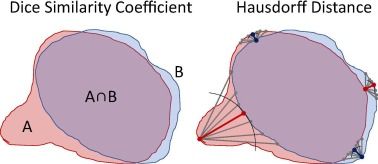</center>

❓ Ahora, proba a aplicar a función de crecemento de rexións no dataset FruitSeg30 e compara os resultados co *ground truth* dispoñible, empregando métricas como o *accuracy*, o *Dice coefficient* ou a distancia de Hausdorff.